In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Reading Data**

In [2]:
customers = pd.read_csv('../data/processed/customers_clean.csv')
orders = pd.read_csv('../data/processed/orders_clean.csv')
order_items = pd.read_csv('../data/processed/order_items_clean.csv')
order_payments = pd.read_csv('../data/processed/order_payments_clean.csv')
order_reviews = pd.read_csv('../data/processed/order_reviews_clean.csv')
products = pd.read_csv('../data/processed/products_clean.csv')
sellers = pd.read_csv('../data/processed/sellers_clean.csv')
locations = pd.read_csv('../data/processed/locations_clean.csv')
product_category = pd.read_csv('../data/processed/product_category_clean.csv')

### **Monthly Sales Trend**

In [3]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [5]:
sales=orders.merge(order_items, on='order_id')

In [6]:
sales=sales[sales['order_status']=='delivered']

In [7]:
sales['order_month']=sales['order_purchase_timestamp'].dt.to_period('M')
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018-02


In [8]:
monthly_revenue=sales.groupby('order_month')['price'].sum()
monthly_revenue

order_month
2016-09       134.97
2016-10     40325.11
2016-12        10.90
2017-01    111798.36
2017-02    234223.40
2017-03    359198.85
2017-04    340669.68
2017-05    489338.25
2017-06    421923.37
2017-07    481604.52
2017-08    554699.70
2017-09    607399.67
2017-10    648247.65
2017-11    987765.37
2017-12    726033.19
2018-01    924645.00
2018-02    826437.13
2018-03    953356.25
2018-04    973534.09
2018-05    977544.69
2018-06    856077.86
2018-07    867953.46
2018-08    838576.64
Freq: M, Name: price, dtype: float64

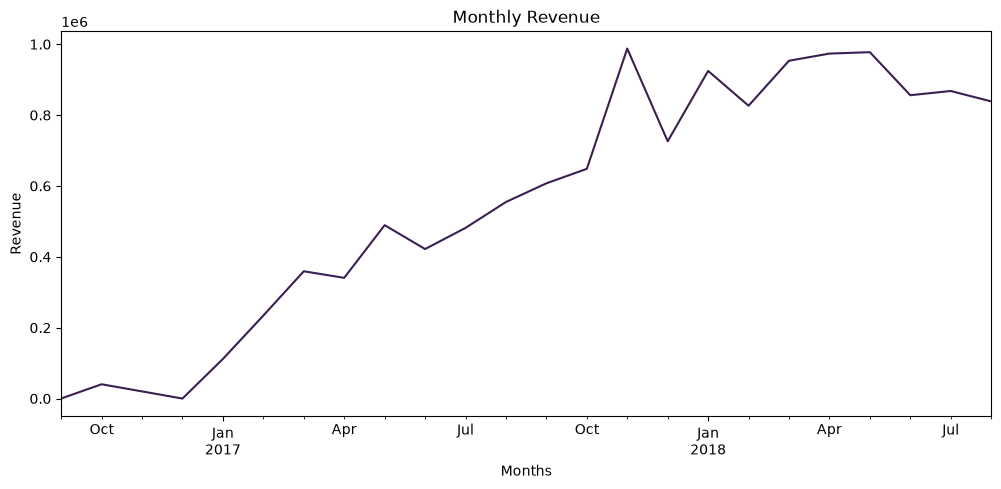

In [9]:
monthly_revenue.plot(kind='line',figsize=(12,5),title='Monthly Revenue',color='#3A1F52')
plt.ylabel('Revenue')
plt.xlabel('Months')
plt.show()

In [10]:
daily_revenue=sales.groupby(sales['order_purchase_timestamp'].dt.floor('D'))['price'].sum()
daily_revenue.sort_index(inplace=True)

In [11]:
daily_revenue.loc['2017-11-01':'2017-11-30'].sort_values(ascending=False).head(10)

order_purchase_timestamp
2017-11-24    149916.58
2017-11-25     59928.51
2017-11-28     47694.76
2017-11-27     47237.27
2017-11-26     44000.48
2017-11-20     43405.98
2017-11-23     43102.33
2017-11-29     39093.09
2017-11-21     33600.85
2017-11-30     30835.85
Name: price, dtype: float64

**Finding:** Daily revenue peaked on November 24, 2017 at $152,653.74, roughly 2.5x higher than the next-highest day in the month (Nov 25: $60,923.48) and 3-4x a typical November day ($35-48k). November 24, 2017 was Black Friday 
in Brazil, making this the clear driver of the November revenue spike seen in 
the monthly trend chart.

### **Product Category Performance**

In [12]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [13]:
product_sales=sales.merge(products, on='product_id',how='left')
product_sales=product_sales.merge(product_category, on='product_category_name',how='left')

**Top Category By Revenue**

In [14]:
catergory_revenue=product_sales.groupby('product_category_name_english')['price'].sum()
catergory_revenue=catergory_revenue.sort_values(ascending=False).head(10)

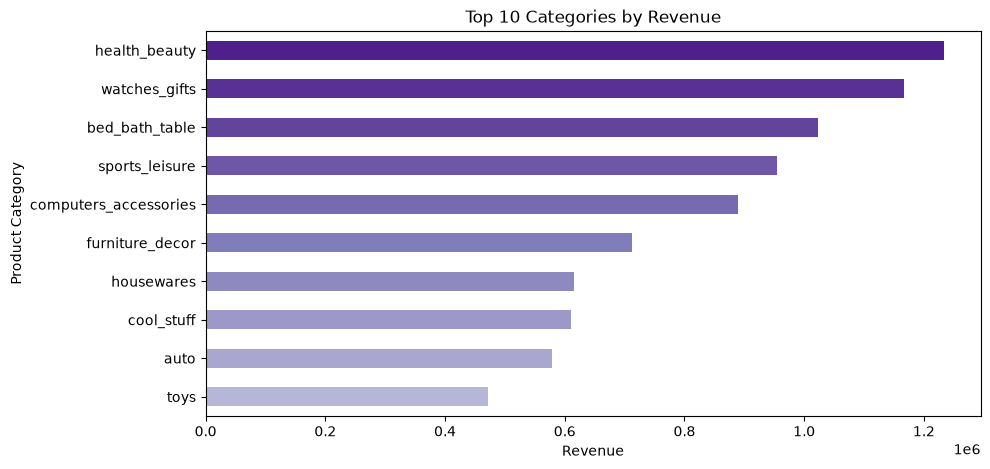

In [15]:
import matplotlib.cm as cm
gradient_colors = cm.Purples(np.linspace(0.9, 0.4, 10))
catergory_revenue.head(10).plot(kind='barh',figsize=(10,5),title='Top 10 Categories by Revenue',color=gradient_colors)
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

**Number of Items Sold per Category**

In [16]:
order_count=product_sales.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)
order_count

product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
Name: order_id, dtype: int64

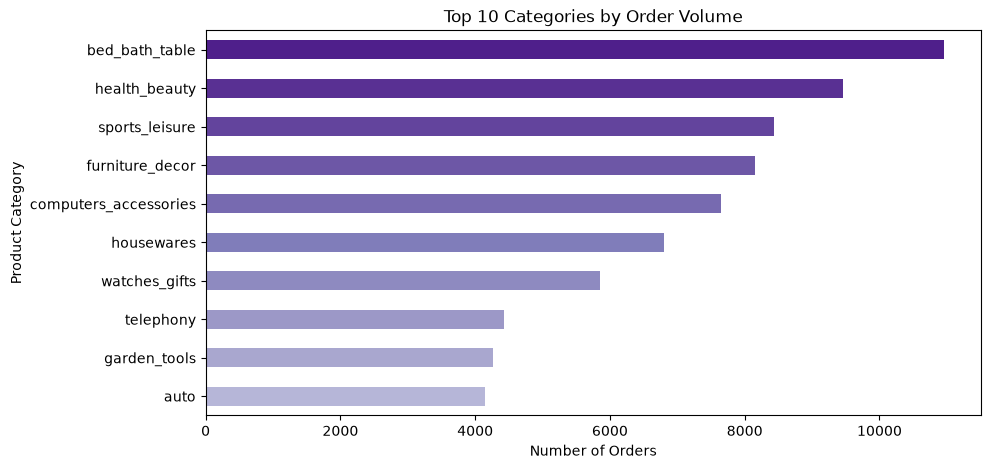

In [17]:
import matplotlib.cm as cm
gradient_colors = cm.Purples(np.linspace(0.9, 0.4, 10))
order_count.head(10).plot(kind='barh',figsize=(10,5),title='Top 10 Categories by Order Volume',color=gradient_colors)
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')
plt.gca().invert_yaxis()
plt.show()

**Average Price per Order**

In [18]:
catergory_revenue_full=product_sales.groupby('product_category_name_english')['price'].sum()
order_count_full=product_sales.groupby('product_category_name_english')['order_id'].count()

avg_price_per_order = (catergory_revenue_full / order_count_full).sort_values(ascending=False)
avg_price_per_order.head(10)

product_category_name_english
computers                                1098.915276
small_appliances_home_oven_and_coffee     638.213151
home_appliances_2                         467.333117
agro_industry_and_commerce                342.553883
musical_instruments                       283.127097
small_appliances                          277.741824
fixed_telephony                           216.922392
construction_tools_safety                 211.875519
watches_gifts                             199.040276
furniture_bedroom                         184.968932
dtype: float64

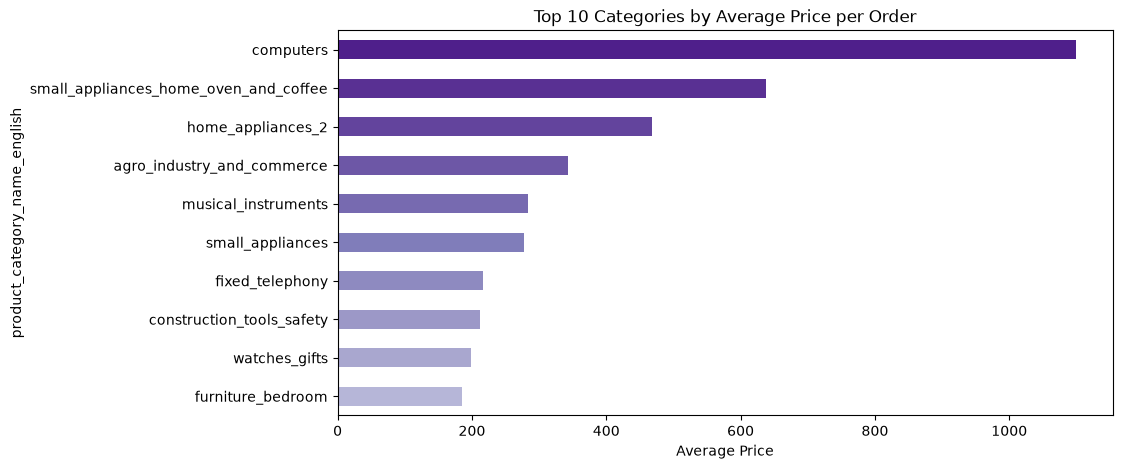

In [19]:
import matplotlib.cm as cm
gradient_colors = cm.Purples(np.linspace(0.9, 0.4, 10))
avg_price_per_order.head(10).plot(kind='barh', figsize=(10,5), title='Top 10 Categories by Average Price per Order',color=gradient_colors)
plt.xlabel('Average Price')
plt.gca().invert_yaxis()
plt.show()

**Finding:** Average price per order varies far more sharply across categories 
than total revenue alone. computers has by far the highest average 
order value ($1,098.92), over 5x higher than the 9th-ranked watches_gifts 
($199.04), despite not appearing in the top 10 by total revenue, indicating 
it's a low-volume, high-value niche category. This shows that "top category" 
depends heavily on which metric is used: bed_bath_table leads by volume, 
health_beauty leads by total revenue, and computers leads by price-per-order,
three different categories.

### **Regional Sales Performance**

In [20]:
sales_region=sales.merge(customers,on='customer_id',how='left')
sales_region=sales_region.merge(locations,left_on='customer_zip_code_prefix',right_on='geolocation_zip_code_prefix',how='left')
sales_region.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'order_month', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state'],
      dtype='str')

**Revenue By State**

In [21]:
state_revenue=sales_region.groupby('customer_state')['price'].sum().sort_values(ascending=False)
state_revenue.head(10)

customer_state
SP    5067633.16
RJ    1759651.13
MG    1552481.83
RS     728897.47
PR     666063.51
SC     507012.13
BA     493584.14
DF     296498.41
GO     282836.70
ES     268643.45
Name: price, dtype: float64

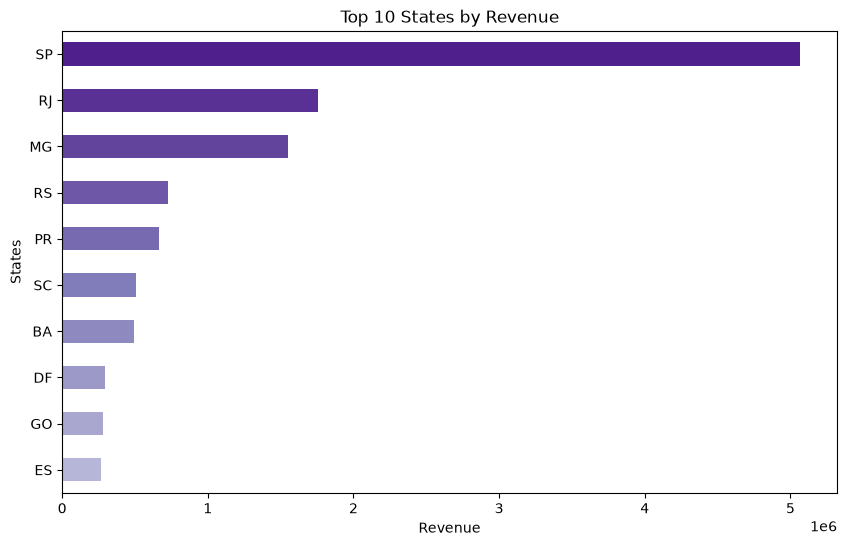

In [22]:
import matplotlib.cm as cm
gradient_colors = cm.Purples(np.linspace(0.9, 0.4, 10))
state_revenue.head(10).plot(kind='barh', figsize=(10,6), title='Top 10 States by Revenue',color=gradient_colors)
plt.xlabel('Revenue')
plt.ylabel('States')
plt.gca().invert_yaxis()
plt.show()

**Order Volume By State**

In [23]:
orders_by_state=sales_region.groupby('customer_state')['order_id'].count().sort_values(ascending=False)
orders_by_state.head(10)

customer_state
SP    46448
RJ    14143
MG    12916
RS     6134
PR     5649
SC     4097
BA     3683
DF     2355
GO     2277
ES     2225
Name: order_id, dtype: int64

In [24]:
total_revenue=sales_region['price'].sum()
sp_share = state_revenue['SP'] / total_revenue * 100
sp_share

np.float64(38.328736409735036)

**Finding:** Sao Paulo(SP) dominates both revenue and order volume, generating 
$5,067,633 across 46,448 orders, nearly 3x the next-highest state (RJ, 
$1,759,651 / 14,143 orders). This represents 38.32% of total revenue indicating heavy concentration.

### **Delivery Performance**

In [25]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [26]:
delivered=orders[orders['order_status']=='delivered'].copy()

In [27]:
delivered['delivery_day']=(delivered['order_delivered_customer_date']-delivered['order_purchase_timestamp']).dt.days

**Delays in Delivery**

In [28]:
delivered['delivery_delay']=(delivered['order_delivered_customer_date']-delivered['order_estimated_delivery_date']).dt.days

In [29]:
delivered['delivery_delay'].describe()


count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

In [30]:
delivered['delivery_day'].describe()

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_day, dtype: float64

**Late Delivery Rate**

In [31]:
late_delivery=(delivered['delivery_delay']>0).mean()* 100
late_delivery

np.float64(6.77252845208234)

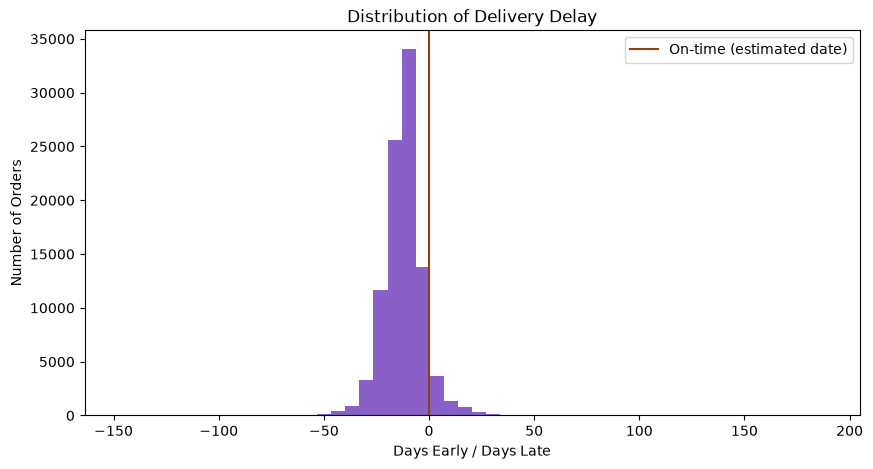

In [32]:
plt.figure(figsize=(10,5))
plt.hist(delivered['delivery_delay'], bins=50, color='#8A5FC7')
plt.axvline(0, color='#943e10', linestyle='-', label='On-time (estimated date)')
plt.title('Distribution of Delivery Delay')
plt.xlabel('Days Early / Days Late')
plt.ylabel('Number of Orders')
plt.legend()
plt.show()

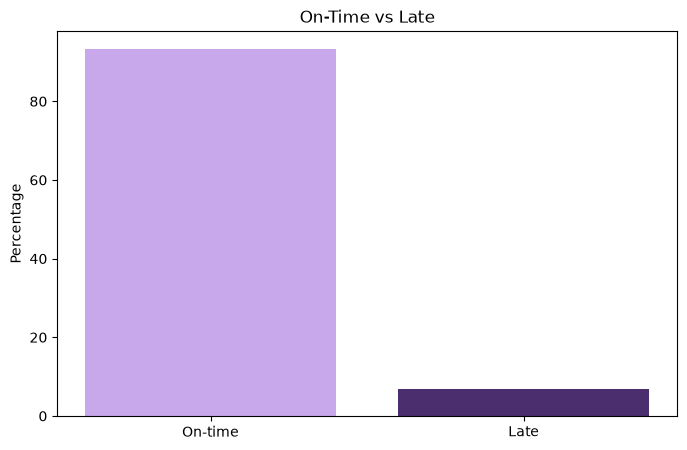

In [33]:
plt.figure(figsize=(8,5))
plt.bar(['On-time', 'Late'], [100 - late_delivery, late_delivery], color=['#C9A7EB', '#4B2E6E'])
plt.title('On-Time vs Late')
plt.ylabel('Percentage')
plt.show()

**Finding:** Orders arrive on average 11.88 days earlier than the estimated delivery date, with an average 
actual delivery time of ~12 days from purchase. Only 6.77% of delivered orders 
arrived after their estimated date, meaning the vast majority (93.23%) were 
delivered on-time or early. The distribution histogram confirms this, most 
orders clusters to the left of the estimated date (early), with a little of late deliveries extending out to as much as 188 days in extreme cases.

### **Customer Behaviour**

In [34]:
order_per_customer=sales_region.groupby('customer_unique_id')['order_id'].nunique()
order_per_customer.describe()

count    93358.000000
mean         1.033420
std          0.209097
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         15.000000
Name: order_id, dtype: float64

**Repeating Customers**

In [35]:
repeated_customers=(order_per_customer>1).sum()
repeated_customers

np.int64(2801)

In [36]:
total_customers=len(order_per_customer)
repeat_rate=(repeated_customers / total_customers) * 100
repeat_rate

np.float64(3.0002784978255748)

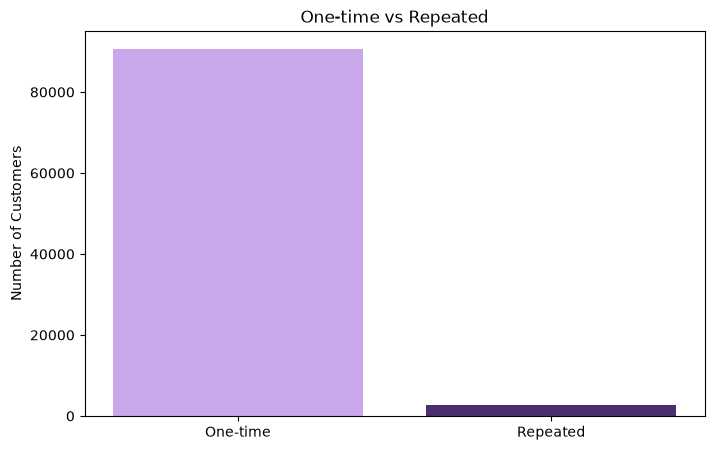

In [37]:
plt.figure(figsize=(8,5))
plt.bar(['One-time', 'Repeated'], 
        [total_customers - repeated_customers, repeated_customers], 
        color=['#C9A7EB', '#4B2E6E'])
plt.title('One-time vs Repeated')
plt.ylabel('Number of Customers')
plt.show()

**Average Order Value**

In [38]:
total_orders=sales_region.groupby('order_id')['price'].sum()
avg_order_value=total_orders.mean()
avg_order_value

np.float64(137.0415857501192)

**Finding:** Repeated customer purchase behavior is very low, only 3.08% of 
customers(2,801 out of 93,358) placed more than one order, with the vast 
majority being one-time buyers.Average Order Value is $137.04 per order.

### **Satisfaction Analysis**

In [39]:
delivery_review=delivered.merge(order_reviews,on='order_id',how='inner')

**Review Score Distribution**

In [40]:
review_score_counts=delivery_review['review_score'].value_counts().sort_index()
review_score_counts

review_score
1     9406
2     2941
3     7961
4    18987
5    57066
Name: count, dtype: int64

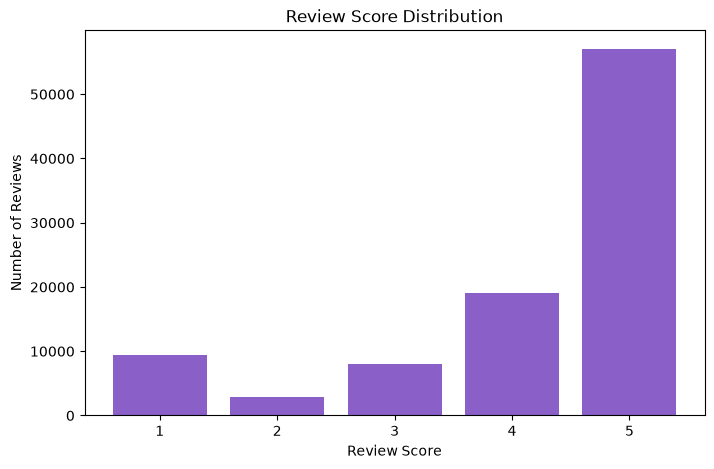

In [41]:
plt.figure(figsize=(8,5))
plt.bar(review_score_counts.index, review_score_counts.values, color='#8A5FC7')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

**Average Review Score by Delivery (Late/Early)**

In [42]:
delivery_review['is_late']=delivery_review['delivery_delay'] > 0

In [43]:
avg_score_by_status=delivery_review.groupby('is_late')['review_score'].mean()
avg_score_by_status

is_late
False    4.289999
True     2.271025
Name: review_score, dtype: float64

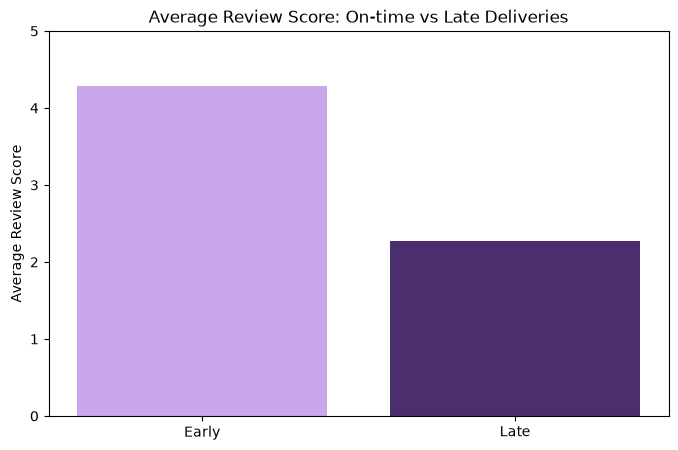

In [44]:
plt.figure(figsize=(8,5))
plt.bar(['Early', 'Late'], avg_score_by_status.values, color=['#C9A7EB', '#4B2E6E'])
plt.title('Average Review Score: On-time vs Late Deliveries')
plt.ylabel('Average Review Score')
plt.ylim(0,5)
plt.show()

**Correlation between Delay and Review Score**

In [45]:
delivery_review[['delivery_delay','review_score']].corr()

,delivery_delay,review_score
delivery_delay,1.000000,-0.267027
review_score,-0.267027,1.000000


**Finding:** Review scores for 5-star reviews account for the largest share (~57,000), followed by 4-star (~19,000), with a secondary 
spike at 1-star (~11,000) reviews, forming a "smile curve" typical of review 
data (customers are most likely to review when very satisfied or very 
dissatisfied).Orders delivered on-time or early average a 4.28 review score, compared to 2.57 for 
late orders. The correlation between delivery_delay 
and review_score is -0.327.

In [48]:
# Build the merged base table for category-level analysis
base = orders.merge(order_items, on='order_id')
base = base.merge(products, on='product_id', how='left')
base = base.merge(product_category, on='product_category_name', how='left')

# Handle orphaned/unmatched categories the same way Tableau does
base['category_cleaned'] = base['product_category_name_english'].fillna('Uncategorized')

# Filter to delivered orders only
base_delivered = base[base['order_status'] == 'delivered']

# Revenue benchmark (compare against Chart_TopCategoriesRevenue)
revenue_check = base_delivered.groupby('category_cleaned')['price'].sum().sort_values(ascending=False)
revenue_check.head(10)

category_cleaned
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
Name: price, dtype: float64

In [49]:
volume_check = base_delivered.groupby('category_cleaned')['order_id'].nunique().sort_values(ascending=False)
volume_check.head(10)

category_cleaned
bed_bath_table           9272
health_beauty            8647
sports_leisure           7530
computers_accessories    6530
furniture_decor          6307
housewares               5743
watches_gifts            5495
telephony                4093
auto                     3810
toys                     3804
Name: order_id, dtype: int64